In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:

df_bank = pd.read_csv("dataset.csv")
df_bank = df_bank.set_index("Bank")
df_bank.drop(['Bank ID', 'Year'], axis=1).describe().round(2)


FileNotFoundError: [Errno 2] No such file or directory: 'dataset.csv'

C:\Users\dimit\AppData\Local\Temp\ipykernel_5184\4102849130.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bank['Cash rate change'].fillna(df_bank['Cash rate change'].mean(), inplace=True)



Model 1 Coefficients (with Fixed Effects):
Intercept                           5.4499
Cash rate                          15.0582
Bank size (Log of Total Assets)    -0.4480
Capital-to-asset ratio              3.1275
Asset growth                       -0.6727
Cost-to-income ratio               -2.4461
Non-interest income ratio          -0.0851
GDP growth                          0.0110
Inflation rate                     -0.0062
dtype: float64
Model 1 R-squared: 0.5615


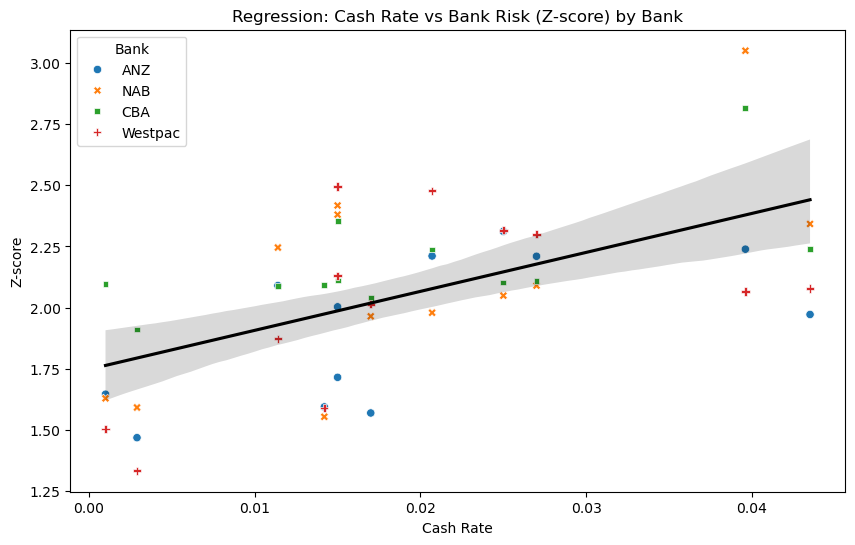


Least Squares Regression Equation:
Z-score = 5.4499 + Cash rate * 15.0582 + Bank size (Log of Total Assets) * -0.4480 + Capital-to-asset ratio * 3.1275 + Asset growth * -0.6727 + Cost-to-income ratio * -2.4461 + Non-interest income ratio * -0.0851 + GDP growth * 0.0110 + Inflation rate * -0.0062

Model 2 Coefficients (with Fixed Effects):
Intercept                           5.8613
Cash rate                         -27.2744
Bank size (Log of Total Assets)    -0.5040
Capital-to-asset ratio             -0.9698
Asset growth                       -0.3850
Cost-to-income ratio               -2.3352
Non-interest income ratio          -0.0304
GDP growth                          0.0208
Inflation rate                      0.1366
dtype: float64
Model 2 R-squared: 0.6095


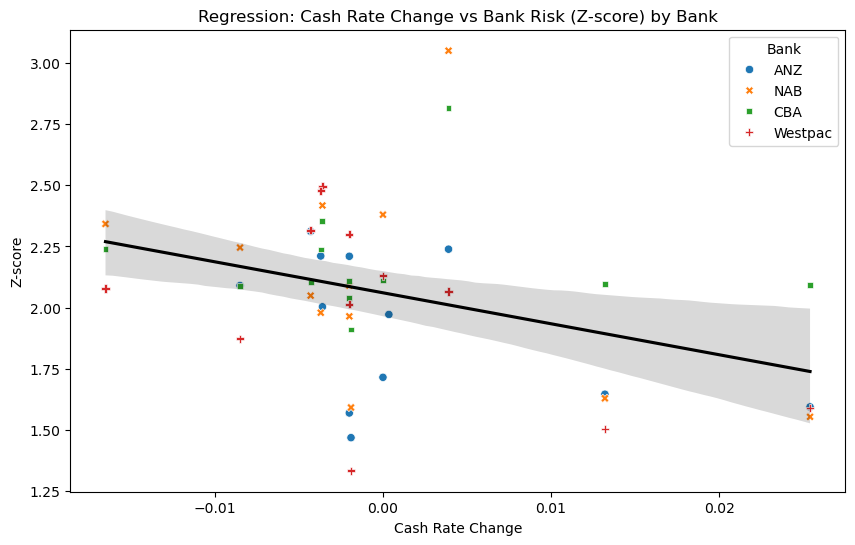

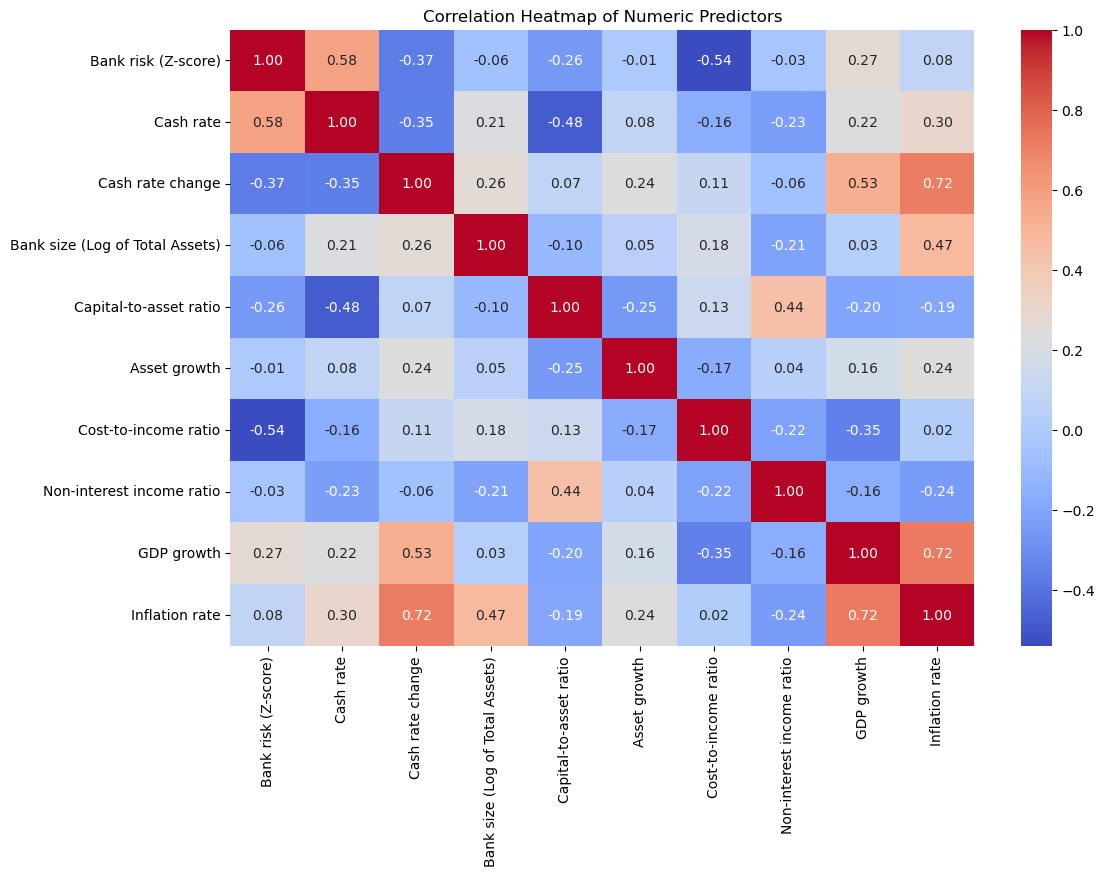

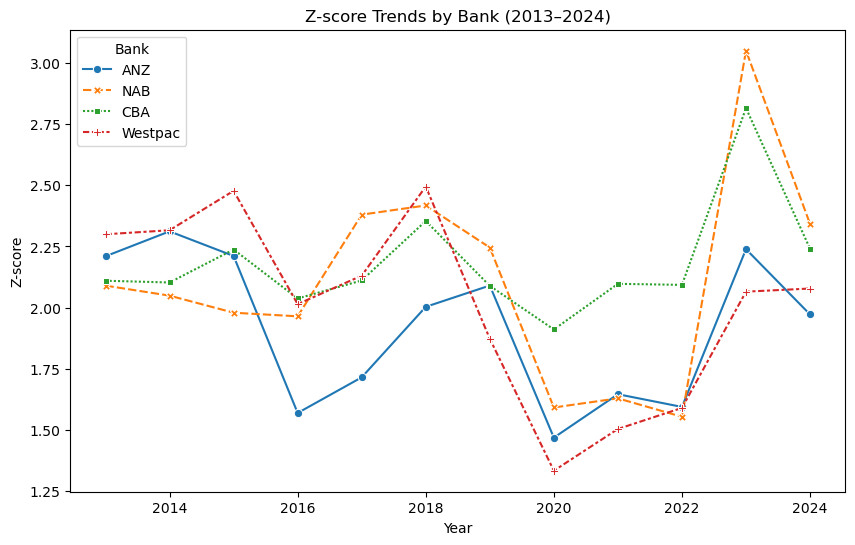

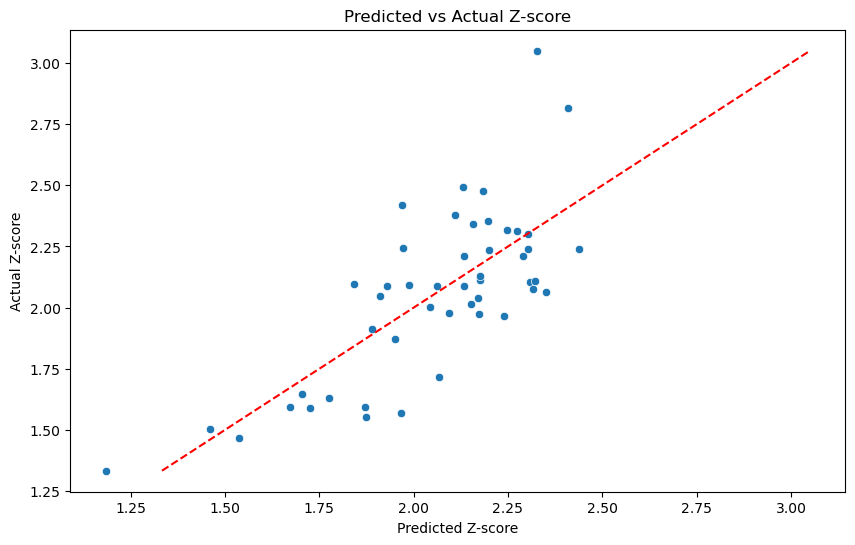

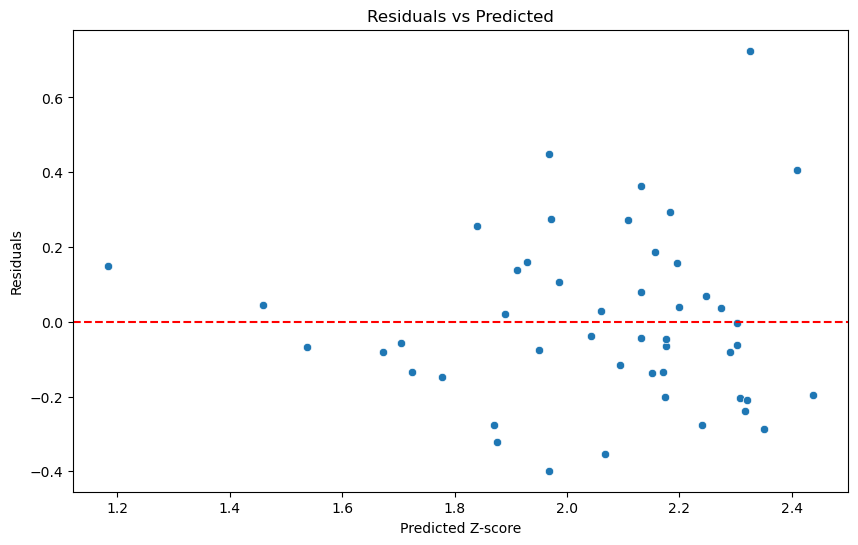

In [10]:
df_bank = df_bank.reset_index()

y = df_bank["Bank risk (Z-score)"]

df_bank['Cash rate change'].fillna(df_bank['Cash rate change'].mean(), inplace=True)
bank_controls = ['Bank size (Log of Total Assets)',
                  'Capital-to-asset ratio', 'Asset growth', 'Cost-to-income ratio', 
                  'Non-interest income ratio']
country_controls = ['GDP growth', 'Inflation rate']

X = df_bank[['Cash rate'] + bank_controls + country_controls].astype(float)

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
coef = pd.Series([model.intercept_] + list(model.coef_), index=['Intercept'] + X.columns.tolist())
print("\nModel 1 Coefficients (with Fixed Effects):")
print(coef.round(4))
print(f"Model 1 R-squared: {r2:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_bank['Cash rate'], y=y, style=df_bank['Bank'], hue=df_bank["Bank"])
sns.regplot(x=df_bank['Cash rate'], y=y, scatter=False, color='black')
plt.title('Regression: Cash Rate vs Bank Risk (Z-score) by Bank')
plt.xlabel('Cash Rate')
plt.ylabel('Z-score')
plt.savefig('cash_rate_change_vs_zscore_by_bank.png')
plt.show()

equation_terms = [f"{coef.index[i]} * {coef.values[i]:.4f}" for i in range(1, len(coef))]
equation_str = f"Z-score = {coef.values[0]:.4f} + " + " + ".join(equation_terms)
print("\nLeast Squares Regression Equation:")
print(equation_str)

X_2 = df_bank[['Cash rate change'] + bank_controls + country_controls].astype(float)

model2 = LinearRegression().fit(X_2, y)
y_pred2 = model2.predict(X_2)
r2_2 = r2_score(y, y_pred2)
coef_2 = pd.Series([model2.intercept_] + list(model2.coef_), index=['Intercept'] + X.columns.tolist())
print("\nModel 2 Coefficients (with Fixed Effects):")
print(coef_2.round(4))
print(f"Model 2 R-squared: {r2_2:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_bank['Cash rate change'], y=y, style=df_bank['Bank'], hue=df_bank["Bank"])
sns.regplot(x=df_bank['Cash rate change'], y=y, scatter=False, color='black')
plt.title('Regression: Cash Rate Change vs Bank Risk (Z-score) by Bank')
plt.xlabel('Cash Rate Change')
plt.ylabel('Z-score')
plt.savefig('cash_rate_change_vs_zscore_by_bank.png')
plt.show()

plt.figure(figsize=(12, 8))
numeric_cols = ['Bank risk (Z-score)', 'Cash rate', 'Cash rate change'] + bank_controls + country_controls
corr = df_bank[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Predictors')
plt.savefig('correlation_heatmap_numeric.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Bank risk (Z-score)', hue='Bank', style='Bank', markers=True, data=df_bank)
plt.title('Z-score Trends by Bank (2013–2024)')
plt.xlabel('Year')
plt.ylabel('Z-score')
plt.savefig('zscore_trends_by_bank.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # y=x
plt.title('Predicted vs Actual Z-score')
plt.xlabel('Predicted Z-score')
plt.ylabel('Actual Z-score')
plt.savefig('predicted_vs_actual_model2.png')
plt.show()

residuals = y - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Z-score')
plt.ylabel('Residuals')
plt.savefig('residuals_model2.png')
plt.show()


In [9]:
# statsmodels
X = df_bank[['Cash rate'] + bank_controls + country_controls].astype(float)
X = sm.add_constant(X) 
y = df_bank["Bank risk (Z-score)"]
model = sm.OLS(y, X).fit()

regression_table = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.round(4),
    't-Statistic': model.tvalues.round(4),
    'p-Value': model.pvalues.round(4)
})

r2_row = pd.DataFrame({
    'Variable': ['R-squared'],
    'Coefficient': [round(model.rsquared, 4)],
    't-Statistic': [""],
    'p-Value': [""]
})
regression_table = pd.concat([regression_table, r2_row], ignore_index=True)

print("\n📊 Regression Table with t-Statistics and p-Values:")
print(regression_table.to_string(index=False))
regression_table.to_excel('regression_table.xlsx', index=False)



📊 Regression Table with t-Statistics and p-Values:
                       Variable  Coefficient t-Statistic p-Value
                          const       5.4499      1.1422  0.2603
                      Cash rate      15.0582      4.2445  0.0001
Bank size (Log of Total Assets)      -0.4480     -0.5735  0.5696
         Capital-to-asset ratio       3.1275      0.3937  0.6959
                   Asset growth      -0.6727     -0.9104  0.3682
           Cost-to-income ratio      -2.4461     -3.3571  0.0018
      Non-interest income ratio      -0.0851     -0.3921  0.6971
                     GDP growth       0.0110      0.1554  0.8773
                 Inflation rate      -0.0062     -0.1303   0.897
                      R-squared       0.5615                    
